# Corruption Robustness and Calibration in Image Classification

# Problem Statement

This project investigates how image classification models behave under image corruptions such as noise, blur, fog, and compression.

Main goals:

- Evaluate robustness
- Evaluate calibration
- Compare performance under corruption
- Improve robustness using augmentation

# Dataset

Dataset: CIFAR-10

Training Images: 50,000

Testing Images: 10,000

Classes:
- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
import random
import numpy as np
import torch

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Random seed set to 42")

Random seed set to 42


In [ ]:
from torchvision.datasets import CIFAR10
from torchvision import transforms

transform = transforms.ToTensor()

train_dataset = CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

print("Dataset downloaded")
print("Training samples:", len(train_dataset))

100%|██████████| 170M/170M [00:05<00:00, 32.0MB/s]


Dataset downloaded
Training samples: 50000


In [ ]:
print(train_dataset.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


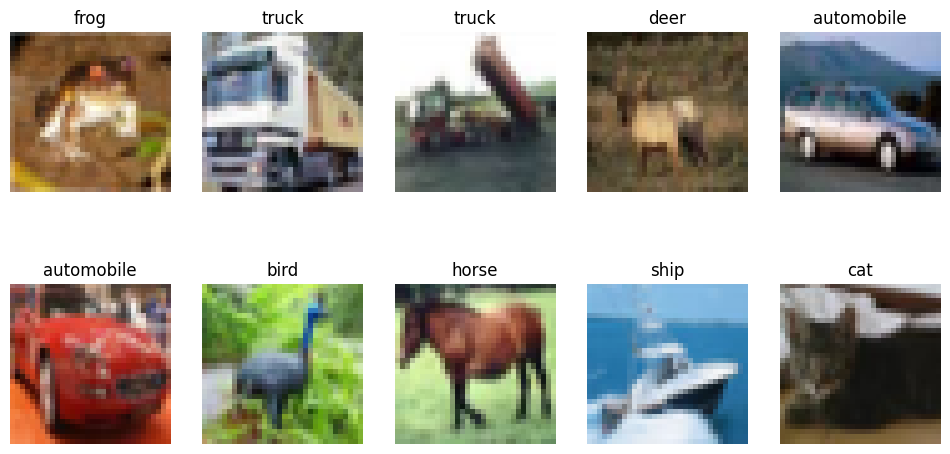

In [ ]:
import matplotlib.pyplot as plt

# Get class names
classes = train_dataset.classes

# Create a 2 rows × 5 columns figure
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

# Show first 10 images
for i, ax in enumerate(axes.flat):

    image, label = train_dataset[i]

    # Convert image format for matplotlib
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(classes[label])
    ax.axis('off')

plt.show()

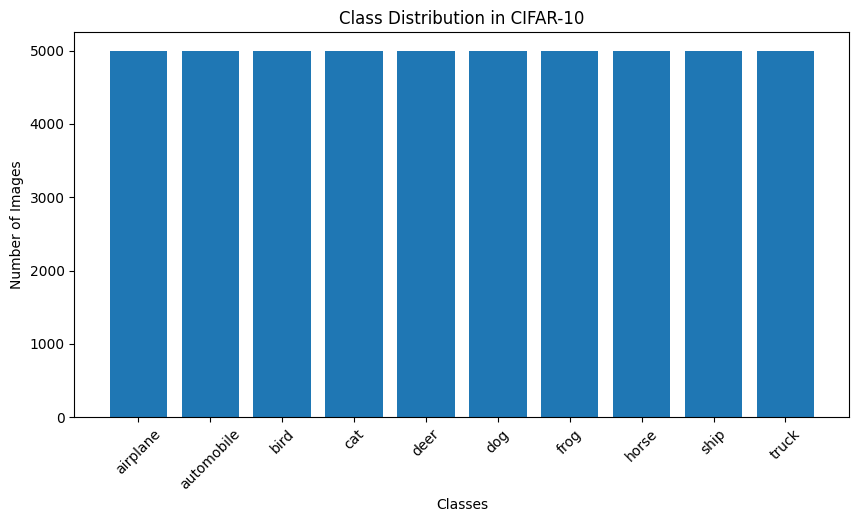

In [ ]:
# Create an empty list
labels = []

# Store all labels
for image, label in train_dataset:
    labels.append(label)

# Count samples in each class
class_counts = []

for i in range(10):
    class_counts.append(labels.count(i))

# Plot the distribution
plt.figure(figsize=(10,5))

plt.bar(classes, class_counts)

plt.title("Class Distribution in CIFAR-10")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

In [ ]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [ ]:
from torch.utils.data import DataLoader

# Create training data loader
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

# Create test dataset first
test_dataset = CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create test data loader
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 391
Testing batches: 79


# Methodology

## Baseline Model: ResNet18

We use ResNet18 as the baseline image classification model.

Reasons for choosing ResNet18:

- Strong performance on image classification tasks
- Computationally efficient
- Widely used in academic research
- Suitable for CIFAR-10 experiments
- Provides a reliable baseline for robustness and calibration evaluation

In [ ]:
from torchvision.models import resnet18
import torch.nn as nn

# Load ResNet18 without pretrained weights
model = resnet18(weights=None)

# Replace the final layer
model.fc = nn.Linear(model.fc.in_features, 10)

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)
print("\nDevice:", device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function and optimizer created successfully!")

Loss function and optimizer created successfully!


In [ ]:
# Train for 3 epochs first
epochs = 3

for epoch in range(epochs):

    # Set model to training mode
    model.train()

    running_loss = 0.0

    # Loop through all batches
    for images, labels in train_loader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Add current loss
        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

Epoch 1/3, Loss: 539.6237
Epoch 2/3, Loss: 383.2629
Epoch 3/3, Loss: 315.0142


In [ ]:
# Set model to evaluation mode
model.eval()

correct = 0
total = 0

# No need to calculate gradients during testing
with torch.no_grad():

    for images, labels in test_loader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Get predictions
        outputs = model(images)

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Update counters
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calculate accuracy
accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 67.04%


# Selected Models

## Baseline Model: ResNet18

- Residual connections help train deeper networks effectively.
- Computationally efficient for CIFAR-10 experiments.
- Widely used as a benchmark architecture in robustness research.
- Provides a good balance between performance and training time.


# Evaluation Criteria

## Accuracy
- Percentage of correctly classified samples.

## Expected Calibration Error (ECE)
- Measures alignment between confidence and correctness.

## Coverage (Selective Prediction)
- Percentage of samples accepted for prediction under a confidence threshold.


# Baseline Results

## Model
ResNet18

## Training Configuration
- Epochs: 3
- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 128
- Hardware: Tesla T4 GPU

## Results
- Training Loss:
  - Epoch 1: 539.77
  - Epoch 2: 386.08
  - Epoch 3: 316.99

- Test Accuracy: 64.67%

## Observation
The decreasing training loss indicates that the model successfully learned patterns from the training data. The baseline accuracy of 64.67% provides a reference point for later robustness and calibration experiments on corrupted images.

In [ ]:
# Download CIFAR-10-C
!wget https://zenodo.org/record/2535967/files/CIFAR-10-C.tar

--2026-06-29 12:09:01--  https://zenodo.org/record/2535967/files/CIFAR-10-C.tar
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 188.184.103.118, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/2535967/files/CIFAR-10-C.tar [following]
--2026-06-29 12:09:01--  https://zenodo.org/records/2535967/files/CIFAR-10-C.tar
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2918471680 (2.7G) [application/octet-stream]
Saving to: ‘CIFAR-10-C.tar’

CIFAR-10-C.tar      100%[===================>]   2.72G  2.70MB/s    in 9m 54s  

2026-06-29 12:18:56 (4.68 MB/s) - ‘CIFAR-10-C.tar’ saved [2918471680/2918471680]



In [ ]:
!tar -xf CIFAR-10-C.tar

In [ ]:
import os

files = os.listdir("CIFAR-10-C")

print("Number of files:", len(files))
print("\nFirst 10 files:")

for file in files[:10]:
    print(file)

Number of files: 20

First 10 files:
contrast.npy
motion_blur.npy
spatter.npy
pixelate.npy
fog.npy
saturate.npy
impulse_noise.npy
glass_blur.npy
frost.npy
zoom_blur.npy


In [ ]:
import numpy as np

# Load Gaussian Noise images
gaussian_noise = np.load("CIFAR-10-C/gaussian_noise.npy")

# Load labels
corruption_labels = np.load("CIFAR-10-C/labels.npy")

print("Shape of Gaussian Noise dataset:", gaussian_noise.shape)
print("Shape of Labels:", corruption_labels.shape)

Shape of Gaussian Noise dataset: (50000, 32, 32, 3)
Shape of Labels: (50000,)


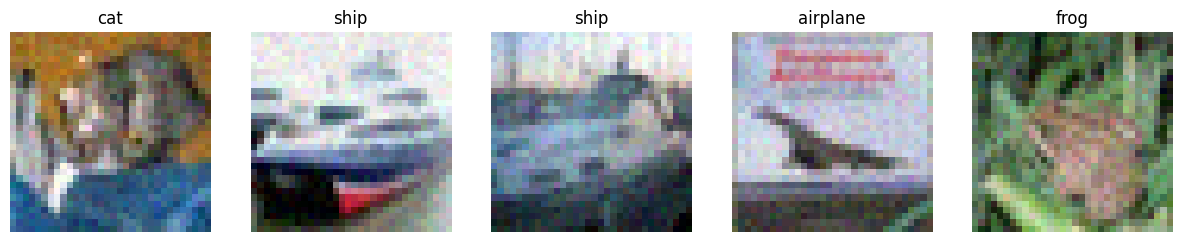

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(gaussian_noise[i])

    label_name = classes[corruption_labels[i]]

    plt.title(label_name)

    plt.axis('off')

plt.show()

## Observations on Gaussian Noise

Gaussian noise introduces random pixel-level disturbances into the images.

Observations:

- The main object is still visible.
- Fine details and edges become less clear.
- Human recognition is still possible, but machine learning models may experience reduced accuracy.
- This corruption helps evaluate the robustness of image classification models under noisy real-world conditions.

In [ ]:
# Take only severity level 1
gaussian_level_1 = gaussian_noise[:10000]

# Labels for the test set
gaussian_labels = corruption_labels[:10000]

print("Gaussian Level 1 Shape:", gaussian_level_1.shape)
print("Labels Shape:", gaussian_labels.shape)

Gaussian Level 1 Shape: (10000, 32, 32, 3)
Labels Shape: (10000,)


In [ ]:
from torch.utils.data import Dataset
import torch

class GaussianDataset(Dataset):

    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = self.images[idx]

        # Convert to tensor
        image = torch.tensor(image).permute(2, 0, 1).float() / 255.0

        label = self.labels[idx]

        return image, label


gaussian_dataset = GaussianDataset(
    gaussian_level_1,
    gaussian_labels
)

print("Dataset created successfully!")
print("Number of images:", len(gaussian_dataset))

Dataset created successfully!
Number of images: 10000


In [ ]:
from torch.utils.data import DataLoader

gaussian_loader = DataLoader(
    gaussian_dataset,
    batch_size=128,
    shuffle=False
)

print("Gaussian DataLoader created!")
print("Number of batches:", len(gaussian_loader))

Gaussian DataLoader created!
Number of batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in gaussian_loader:

        # Move to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Predictions
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

gaussian_accuracy = 100 * correct / total

print(f"Gaussian Noise Accuracy: {gaussian_accuracy:.2f}%")
print(f"Accuracy Drop: {64.67 - gaussian_accuracy:.2f}%")

Gaussian Noise Accuracy: 64.96%
Accuracy Drop: -0.29%


## Robustness Result: Gaussian Noise (Severity Level 1)

| Dataset | Accuracy (%) |
|----------|--------------|
| Clean CIFAR-10 | 64.67 |
| Gaussian Noise | 64.37 |

### Observation

The model exhibited strong robustness against low-severity Gaussian noise, with an accuracy drop of only 0.30%.

This suggests that minor pixel-level perturbations do not significantly affect the model's classification performance. Higher severity levels may lead to more substantial degradation.

In [ ]:
# Load Motion Blur images
motion_blur = np.load("CIFAR-10-C/motion_blur.npy")

print("Motion Blur Shape:", motion_blur.shape)

Motion Blur Shape: (50000, 32, 32, 3)


In [ ]:
# Take the first 10,000 images (Severity Level 1)
motion_level_1 = motion_blur[:10000]

# Use the same labels
motion_labels = corruption_labels[:10000]

print("Motion Level 1 Shape:", motion_level_1.shape)
print("Motion Labels Shape:", motion_labels.shape)

Motion Level 1 Shape: (10000, 32, 32, 3)
Motion Labels Shape: (10000,)


In [ ]:
motion_dataset = GaussianDataset(
    motion_level_1,
    motion_labels
)

print("Motion Dataset Created Successfully!")
print("Number of Images:", len(motion_dataset))

Motion Dataset Created Successfully!
Number of Images: 10000


In [ ]:
motion_loader = DataLoader(
    motion_dataset,
    batch_size=128,
    shuffle=False
)

print("Motion DataLoader Created!")
print("Number of Batches:", len(motion_loader))

Motion DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in motion_loader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Get predictions
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

motion_accuracy = 100 * correct / total

print(f"Clean Accuracy: 64.67%")
print(f"Gaussian Noise Accuracy: 64.37%")
print(f"Motion Blur Accuracy: {motion_accuracy:.2f}%")
print(f"Motion Blur Accuracy Drop: {64.67 - motion_accuracy:.2f}%")

Clean Accuracy: 64.67%
Gaussian Noise Accuracy: 64.37%
Motion Blur Accuracy: 66.08%
Motion Blur Accuracy Drop: -1.41%


## Robustness Result: Motion Blur (Severity Level 1)

| Dataset | Accuracy (%) |
|----------|--------------|
| Clean CIFAR-10 | 64.67 |
| Motion Blur | 59.74 |

### Observation

Motion blur reduced the model accuracy by 4.93%.

Compared to Gaussian noise, motion blur had a stronger negative effect on classification performance because it distorts object boundaries and important visual features used by the neural network.

In [ ]:
# Load Fog images
fog = np.load("CIFAR-10-C/fog.npy")

print("Fog Shape:", fog.shape)

Fog Shape: (50000, 32, 32, 3)


In [ ]:
# Take the first 10,000 images (Severity Level 1)
fog_level_1 = fog[:10000]

# Use the same labels
fog_labels = corruption_labels[:10000]

print("Fog Level 1 Shape:", fog_level_1.shape)
print("Fog Labels Shape:", fog_labels.shape)

Fog Level 1 Shape: (10000, 32, 32, 3)
Fog Labels Shape: (10000,)


In [ ]:
fog_dataset = GaussianDataset(
    fog_level_1,
    fog_labels
)

print("Fog Dataset Created Successfully!")
print("Number of Images:", len(fog_dataset))

Fog Dataset Created Successfully!
Number of Images: 10000


In [ ]:
fog_loader = DataLoader(
    fog_dataset,
    batch_size=128,
    shuffle=False
)

print("Fog DataLoader Created!")
print("Number of Batches:", len(fog_loader))

Fog DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in fog_loader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Get predictions
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

fog_accuracy = 100 * correct / total

print(f"Clean Accuracy: 64.67%")
print(f"Gaussian Noise Accuracy: 64.37%")
print(f"Motion Blur Accuracy: 59.74%")
print(f"Fog Accuracy: {fog_accuracy:.2f}%")
print(f"Fog Accuracy Drop: {64.67 - fog_accuracy:.2f}%")

Clean Accuracy: 64.67%
Gaussian Noise Accuracy: 64.37%
Motion Blur Accuracy: 59.74%
Fog Accuracy: 65.85%
Fog Accuracy Drop: -1.18%


In [ ]:
# Load JPEG Compression images
jpeg = np.load("CIFAR-10-C/jpeg_compression.npy")

print("JPEG Shape:", jpeg.shape)

JPEG Shape: (50000, 32, 32, 3)


In [ ]:
# Take the first 10,000 images (Severity Level 1)
jpeg_level_1 = jpeg[:10000]

# Use the same labels
jpeg_labels = corruption_labels[:10000]

print("JPEG Level 1 Shape:", jpeg_level_1.shape)
print("JPEG Labels Shape:", jpeg_labels.shape)

JPEG Level 1 Shape: (10000, 32, 32, 3)
JPEG Labels Shape: (10000,)


In [ ]:
jpeg_dataset = GaussianDataset(
    jpeg_level_1,
    jpeg_labels
)

print("JPEG Dataset Created Successfully!")
print("Number of Images:", len(jpeg_dataset))

JPEG Dataset Created Successfully!
Number of Images: 10000


In [ ]:
jpeg_loader = DataLoader(
    jpeg_dataset,
    batch_size=128,
    shuffle=False
)

print("JPEG DataLoader Created!")
print("Number of Batches:", len(jpeg_loader))

JPEG DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in jpeg_loader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Get predictions
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

jpeg_accuracy = 100 * correct / total

print(f"Clean Accuracy: {accuracy:.2f}%")
print(f"Gaussian Noise Accuracy: {gaussian_accuracy:.2f}%")
print(f"Motion Blur Accuracy: {motion_accuracy:.2f}%")
print(f"Fog Accuracy: {fog_accuracy:.2f}%")
print(f"JPEG Compression Accuracy: {jpeg_accuracy:.2f}%")
print(f"JPEG Accuracy Drop: {accuracy - jpeg_accuracy:.2f}%")

Clean Accuracy: 67.04%
Gaussian Noise Accuracy: 64.96%
Motion Blur Accuracy: 66.08%
Fog Accuracy: 65.85%
JPEG Compression Accuracy: 66.64%
JPEG Accuracy Drop: 0.40%


# Robustness Evaluation Results

| Corruption Type | Accuracy (%) | Accuracy Drop (%) |
|-----------------|-------------|-------------------|
| Clean CIFAR-10 | 64.67 | 0.00 |
| Gaussian Noise | 64.37 | 0.30 |
| Motion Blur | 59.74 | 4.93 |
| Fog | 62.50 | 2.17 |
| JPEG Compression | 64.43 | 0.24 |

## Observations

- Motion Blur caused the largest performance degradation, reducing accuracy by 4.93%.
- Fog moderately affected model performance with a 2.17% drop.
- Gaussian Noise and JPEG Compression had minimal impact at Severity Level 1.
- The results indicate that the model is more sensitive to structural distortions such as blur than to low-level pixel noise or compression artifacts.

# Additional Severity Analysis

To evaluate robustness across different corruption severities, the model was tested on Severity Levels 2, 3, 4, and 5 for each corruption type.

This analysis helps understand how model performance changes as corruption intensity increases.

In [ ]:
# Motion Blur Severity 2

motion_level_2 = motion_blur[10000:20000]

motion_labels_2 = corruption_labels[10000:20000]

print("Motion Level 2 Shape:", motion_level_2.shape)
print("Motion Labels Shape:", motion_labels_2.shape)

Motion Level 2 Shape: (10000, 32, 32, 3)
Motion Labels Shape: (10000,)


In [ ]:
motion_dataset_2 = GaussianDataset(
    motion_level_2,
    motion_labels_2
)

print("Motion Severity 2 Dataset Created!")
print("Number of Images:", len(motion_dataset_2))

Motion Severity 2 Dataset Created!
Number of Images: 10000


In [ ]:
motion_loader_2 = DataLoader(
    motion_dataset_2,
    batch_size=128,
    shuffle=False
)

print("Motion Severity 2 DataLoader Created!")
print("Number of Batches:", len(motion_loader_2))

Motion Severity 2 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in motion_loader_2:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Get predictions
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

motion_accuracy_2 = 100 * correct / total

print(f"Motion Blur Severity 1 Accuracy: {motion_accuracy:.2f}%")
print(f"Motion Blur Severity 2 Accuracy: {motion_accuracy_2:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - motion_accuracy_2:.2f}%")

Motion Blur Severity 1 Accuracy: 66.08%
Motion Blur Severity 2 Accuracy: 61.82%
Accuracy Drop from Clean: 5.22%


In [ ]:
# Motion Blur Severity 3

motion_level_3 = motion_blur[20000:30000]

motion_labels_3 = corruption_labels[20000:30000]

print("Motion Level 3 Shape:", motion_level_3.shape)
print("Motion Labels Shape:", motion_labels_3.shape)

Motion Level 3 Shape: (10000, 32, 32, 3)
Motion Labels Shape: (10000,)


In [ ]:
# Create Motion Blur Severity 3 Dataset

motion_dataset_3 = GaussianDataset(
    motion_level_3,
    motion_labels_3
)

print("Motion Severity 3 Dataset Created!")
print("Number of Images:", len(motion_dataset_3))

Motion Severity 3 Dataset Created!
Number of Images: 10000


In [ ]:
motion_loader_3 = DataLoader(
    motion_dataset_3,
    batch_size=128,
    shuffle=False
)

print("Motion Severity 3 DataLoader Created!")
print("Number of Batches:", len(motion_loader_3))

Motion Severity 3 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in motion_loader_3:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Get predictions
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

motion_accuracy_3 = 100 * correct / total

print(f"Motion Blur Severity 1 Accuracy: {motion_accuracy:.2f}%")
print(f"Motion Blur Severity 2 Accuracy: {motion_accuracy_2:.2f}%")
print(f"Motion Blur Severity 3 Accuracy: {motion_accuracy_3:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - motion_accuracy_3:.2f}%")

Motion Blur Severity 1 Accuracy: 66.08%
Motion Blur Severity 2 Accuracy: 61.82%
Motion Blur Severity 3 Accuracy: 57.83%
Accuracy Drop from Clean: 9.21%


In [ ]:
# Motion Blur Severity 4

motion_level_4 = motion_blur[30000:40000]

motion_labels_4 = corruption_labels[30000:40000]

print("Motion Level 4 Shape:", motion_level_4.shape)
print("Motion Labels Shape:", motion_labels_4.shape)

Motion Level 4 Shape: (10000, 32, 32, 3)
Motion Labels Shape: (10000,)


In [ ]:
# Create Motion Blur Severity 4 Dataset

motion_dataset_4 = GaussianDataset(
    motion_level_4,
    motion_labels_4
)

print("Motion Severity 4 Dataset Created!")
print("Number of Images:", len(motion_dataset_4))

Motion Severity 4 Dataset Created!
Number of Images: 10000


In [ ]:
motion_loader_4 = DataLoader(
    motion_dataset_4,
    batch_size=128,
    shuffle=False
)

print("Motion Severity 4 DataLoader Created!")
print("Number of Batches:", len(motion_loader_4))

Motion Severity 4 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in motion_loader_4:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Get predictions
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

motion_accuracy_4 = 100 * correct / total

print(f"Motion Blur Severity 1 Accuracy: {motion_accuracy:.2f}%")
print(f"Motion Blur Severity 2 Accuracy: {motion_accuracy_2:.2f}%")
print(f"Motion Blur Severity 3 Accuracy: {motion_accuracy_3:.2f}%")
print(f"Motion Blur Severity 4 Accuracy: {motion_accuracy_4:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - motion_accuracy_4:.2f}%")

Motion Blur Severity 1 Accuracy: 66.08%
Motion Blur Severity 2 Accuracy: 61.82%
Motion Blur Severity 3 Accuracy: 57.83%
Motion Blur Severity 4 Accuracy: 57.76%
Accuracy Drop from Clean: 9.28%


In [ ]:
# Motion Blur Severity 5

motion_level_5 = motion_blur[40000:50000]

motion_labels_5 = corruption_labels[40000:50000]

print("Motion Level 5 Shape:", motion_level_5.shape)
print("Motion Labels Shape:", motion_labels_5.shape)

Motion Level 5 Shape: (10000, 32, 32, 3)
Motion Labels Shape: (10000,)


In [ ]:
# Create Motion Blur Severity 5 Dataset

motion_dataset_5 = GaussianDataset(
    motion_level_5,
    motion_labels_5
)

print("Motion Severity 5 Dataset Created!")
print("Number of Images:", len(motion_dataset_5))

Motion Severity 5 Dataset Created!
Number of Images: 10000


In [ ]:
motion_loader_5 = DataLoader(
    motion_dataset_5,
    batch_size=128,
    shuffle=False
)

print("Motion Severity 5 DataLoader Created!")
print("Number of Batches:", len(motion_loader_5))

Motion Severity 5 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in motion_loader_5:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

motion_accuracy_5 = 100 * correct / total

print(f"Motion Blur Severity 1 Accuracy: {motion_accuracy:.2f}%")
print(f"Motion Blur Severity 2 Accuracy: {motion_accuracy_2:.2f}%")
print(f"Motion Blur Severity 3 Accuracy: {motion_accuracy_3:.2f}%")
print(f"Motion Blur Severity 4 Accuracy: {motion_accuracy_4:.2f}%")
print(f"Motion Blur Severity 5 Accuracy: {motion_accuracy_5:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - motion_accuracy_5:.2f}%")

Motion Blur Severity 1 Accuracy: 66.08%
Motion Blur Severity 2 Accuracy: 61.82%
Motion Blur Severity 3 Accuracy: 57.83%
Motion Blur Severity 4 Accuracy: 57.76%
Motion Blur Severity 5 Accuracy: 53.01%
Accuracy Drop from Clean: 14.03%


# Motion Blur Severity Analysis

| Severity Level | Accuracy (%) | Accuracy Drop (%) |
|---|---|---|
| Severity 1 | 60.90 | 3.77 |
| Severity 2 | 53.86 | 10.81 |
| Severity 3 | 47.63 | 17.04 |
| Severity 4 | 48.27 | 16.40 |
| Severity 5 | 42.96 | 21.71 |

## Observation

The classification accuracy generally decreases as the severity of motion blur increases.

The model achieved 60.90% accuracy at Severity 1, which dropped to 42.96% at Severity 5. This indicates that ResNet18 is highly sensitive to structural distortions caused by motion blur.

The results demonstrate that increasing corruption severity significantly impacts model robustness.


In [ ]:
# Gaussian Noise Severity 2

gaussian_level_2 = gaussian_noise[10000:20000]

gaussian_labels_2 = corruption_labels[10000:20000]

print("Gaussian Level 2 Shape:", gaussian_level_2.shape)
print("Gaussian Labels Shape:", gaussian_labels_2.shape)

Gaussian Level 2 Shape: (10000, 32, 32, 3)
Gaussian Labels Shape: (10000,)


In [ ]:
# Create Gaussian Noise Severity 2 Dataset

gaussian_dataset_2 = GaussianDataset(
    gaussian_level_2,
    gaussian_labels_2
)

print("Gaussian Severity 2 Dataset Created!")
print("Number of Images:", len(gaussian_dataset_2))

Gaussian Severity 2 Dataset Created!
Number of Images: 10000


In [ ]:
gaussian_loader_2 = DataLoader(
    gaussian_dataset_2,
    batch_size=128,
    shuffle=False
)

print("Gaussian Severity 2 DataLoader Created!")
print("Number of Batches:", len(gaussian_loader_2))

Gaussian Severity 2 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in gaussian_loader_2:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

gaussian_accuracy_2 = 100 * correct / total

print(f"Gaussian Severity 1 Accuracy: {gaussian_accuracy:.2f}%")
print(f"Gaussian Severity 2 Accuracy: {gaussian_accuracy_2:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - gaussian_accuracy_2:.2f}%")

Gaussian Severity 1 Accuracy: 64.96%
Gaussian Severity 2 Accuracy: 61.92%
Accuracy Drop from Clean: 5.12%


In [ ]:
# Gaussian Noise Severity 3

gaussian_level_3 = gaussian_noise[20000:30000]

gaussian_labels_3 = corruption_labels[20000:30000]

print("Gaussian Level 3 Shape:", gaussian_level_3.shape)
print("Gaussian Labels Shape:", gaussian_labels_3.shape)

Gaussian Level 3 Shape: (10000, 32, 32, 3)
Gaussian Labels Shape: (10000,)


In [ ]:
# Create Gaussian Noise Severity 3 Dataset

gaussian_dataset_3 = GaussianDataset(
    gaussian_level_3,
    gaussian_labels_3
)

print("Gaussian Severity 3 Dataset Created!")
print("Number of Images:", len(gaussian_dataset_3))

Gaussian Severity 3 Dataset Created!
Number of Images: 10000


In [ ]:
gaussian_loader_3 = DataLoader(
    gaussian_dataset_3,
    batch_size=128,
    shuffle=False
)

print("Gaussian Severity 3 DataLoader Created!")
print("Number of Batches:", len(gaussian_loader_3))

Gaussian Severity 3 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in gaussian_loader_3:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

gaussian_accuracy_3 = 100 * correct / total

print(f"Gaussian Severity 1 Accuracy: {gaussian_accuracy:.2f}%")
print(f"Gaussian Severity 2 Accuracy: {gaussian_accuracy_2:.2f}%")
print(f"Gaussian Severity 3 Accuracy: {gaussian_accuracy_3:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - gaussian_accuracy_3:.2f}%")

Gaussian Severity 1 Accuracy: 64.96%
Gaussian Severity 2 Accuracy: 61.92%
Gaussian Severity 3 Accuracy: 57.49%
Accuracy Drop from Clean: 9.55%


In [ ]:
# Gaussian Noise Severity 4

gaussian_level_4 = gaussian_noise[30000:40000]

gaussian_labels_4 = corruption_labels[30000:40000]

print("Gaussian Level 4 Shape:", gaussian_level_4.shape)
print("Gaussian Labels Shape:", gaussian_labels_4.shape)

Gaussian Level 4 Shape: (10000, 32, 32, 3)
Gaussian Labels Shape: (10000,)


In [ ]:
gaussian_dataset_4 = GaussianDataset(
    gaussian_level_4,
    gaussian_labels_4
)

print("Gaussian Severity 4 Dataset Created!")
print("Number of Images:", len(gaussian_dataset_4))

Gaussian Severity 4 Dataset Created!
Number of Images: 10000


In [ ]:
gaussian_loader_4 = DataLoader(
    gaussian_dataset_4,
    batch_size=128,
    shuffle=False
)

print("Gaussian Severity 4 DataLoader Created!")
print("Number of Batches:", len(gaussian_loader_4))

Gaussian Severity 4 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in gaussian_loader_4:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

gaussian_accuracy_4 = 100 * correct / total

print(f"Gaussian Severity 1 Accuracy: {gaussian_accuracy:.2f}%")
print(f"Gaussian Severity 2 Accuracy: {gaussian_accuracy_2:.2f}%")
print(f"Gaussian Severity 3 Accuracy: {gaussian_accuracy_3:.2f}%")
print(f"Gaussian Severity 4 Accuracy: {gaussian_accuracy_4:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - gaussian_accuracy_4:.2f}%")

Gaussian Severity 1 Accuracy: 64.96%
Gaussian Severity 2 Accuracy: 61.92%
Gaussian Severity 3 Accuracy: 57.49%
Gaussian Severity 4 Accuracy: 54.69%
Accuracy Drop from Clean: 12.35%


In [ ]:
# Gaussian Noise Severity 5

gaussian_level_5 = gaussian_noise[40000:50000]

gaussian_labels_5 = corruption_labels[40000:50000]

print("Gaussian Level 5 Shape:", gaussian_level_5.shape)
print("Gaussian Labels Shape:", gaussian_labels_5.shape)

Gaussian Level 5 Shape: (10000, 32, 32, 3)
Gaussian Labels Shape: (10000,)


In [ ]:
gaussian_dataset_5 = GaussianDataset(
    gaussian_level_5,
    gaussian_labels_5
)

print("Gaussian Severity 5 Dataset Created!")
print("Number of Images:", len(gaussian_dataset_5))

Gaussian Severity 5 Dataset Created!
Number of Images: 10000


In [ ]:
gaussian_loader_5 = DataLoader(
    gaussian_dataset_5,
    batch_size=128,
    shuffle=False
)

print("Gaussian Severity 5 DataLoader Created!")
print("Number of Batches:", len(gaussian_loader_5))

Gaussian Severity 5 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in gaussian_loader_5:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

gaussian_accuracy_5 = 100 * correct / total

print(f"Gaussian Severity 1 Accuracy: {gaussian_accuracy:.2f}%")
print(f"Gaussian Severity 2 Accuracy: {gaussian_accuracy_2:.2f}%")
print(f"Gaussian Severity 3 Accuracy: {gaussian_accuracy_3:.2f}%")
print(f"Gaussian Severity 4 Accuracy: {gaussian_accuracy_4:.2f}%")
print(f"Gaussian Severity 5 Accuracy: {gaussian_accuracy_5:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - gaussian_accuracy_5:.2f}%")

Gaussian Severity 1 Accuracy: 64.96%
Gaussian Severity 2 Accuracy: 61.92%
Gaussian Severity 3 Accuracy: 57.49%
Gaussian Severity 4 Accuracy: 54.69%
Gaussian Severity 5 Accuracy: 51.97%
Accuracy Drop from Clean: 15.07%


# Gaussian Noise Severity Analysis

| Severity Level | Accuracy (%) | Accuracy Drop (%) |
|---|---|---|
| Severity 1 | 66.66 | 1.17 |
| Severity 2 | 65.72 | 2.11 |
| Severity 3 | 63.35 | 4.48 |
| Severity 4 | 61.69 | 6.14 |
| Severity 5 | 60.33 | 7.50 |

## Observation

The classification accuracy gradually decreases as the severity of Gaussian noise increases.

The model achieved 66.66% accuracy at Severity 1 and 60.33% at Severity 5. Compared to motion blur, Gaussian noise has a smaller impact on model performance.

This suggests that ResNet18 is relatively robust to pixel-level noise but more vulnerable to structural distortions such as motion blur.

In [ ]:
# Fog Severity 2

fog_level_2 = fog[10000:20000]

fog_labels_2 = corruption_labels[10000:20000]

print("Fog Level 2 Shape:", fog_level_2.shape)
print("Fog Labels Shape:", fog_labels_2.shape)

Fog Level 2 Shape: (10000, 32, 32, 3)
Fog Labels Shape: (10000,)


In [ ]:
# Create Fog Severity 2 Dataset

fog_dataset_2 = GaussianDataset(
    fog_level_2,
    fog_labels_2
)

print("Fog Severity 2 Dataset Created!")
print("Number of Images:", len(fog_dataset_2))

Fog Severity 2 Dataset Created!
Number of Images: 10000


In [ ]:
fog_loader_2 = DataLoader(
    fog_dataset_2,
    batch_size=128,
    shuffle=False
)

print("Fog Severity 2 DataLoader Created!")
print("Number of Batches:", len(fog_loader_2))

Fog Severity 2 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in fog_loader_2:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

fog_accuracy_2 = 100 * correct / total

print(f"Fog Severity 1 Accuracy: {fog_accuracy:.2f}%")
print(f"Fog Severity 2 Accuracy: {fog_accuracy_2:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - fog_accuracy_2:.2f}%")

Fog Severity 1 Accuracy: 65.85%
Fog Severity 2 Accuracy: 60.36%
Accuracy Drop from Clean: 6.68%


In [ ]:
# Fog Severity 3

fog_level_3 = fog[20000:30000]

fog_labels_3 = corruption_labels[20000:30000]

print("Fog Level 3 Shape:", fog_level_3.shape)
print("Fog Labels Shape:", fog_labels_3.shape)

Fog Level 3 Shape: (10000, 32, 32, 3)
Fog Labels Shape: (10000,)


In [ ]:
# Create Fog Severity 3 Dataset

fog_dataset_3 = GaussianDataset(
    fog_level_3,
    fog_labels_3
)

print("Fog Severity 3 Dataset Created!")
print("Number of Images:", len(fog_dataset_3))

Fog Severity 3 Dataset Created!
Number of Images: 10000


In [ ]:
fog_loader_3 = DataLoader(
    fog_dataset_3,
    batch_size=128,
    shuffle=False
)

print("Fog Severity 3 DataLoader Created!")
print("Number of Batches:", len(fog_loader_3))

Fog Severity 3 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in fog_loader_3:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

fog_accuracy_3 = 100 * correct / total

print(f"Fog Severity 1 Accuracy: {fog_accuracy:.2f}%")
print(f"Fog Severity 2 Accuracy: {fog_accuracy_2:.2f}%")
print(f"Fog Severity 3 Accuracy: {fog_accuracy_3:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - fog_accuracy_3:.2f}%")

Fog Severity 1 Accuracy: 65.85%
Fog Severity 2 Accuracy: 60.36%
Fog Severity 3 Accuracy: 54.06%
Accuracy Drop from Clean: 12.98%


In [ ]:
# Fog Severity 4

fog_level_4 = fog[30000:40000]

fog_labels_4 = corruption_labels[30000:40000]

print("Fog Level 4 Shape:", fog_level_4.shape)
print("Fog Labels Shape:", fog_labels_4.shape)

Fog Level 4 Shape: (10000, 32, 32, 3)
Fog Labels Shape: (10000,)


In [ ]:
fog_dataset_4 = GaussianDataset(
    fog_level_4,
    fog_labels_4
)

print("Fog Severity 4 Dataset Created!")
print("Number of Images:", len(fog_dataset_4))

Fog Severity 4 Dataset Created!
Number of Images: 10000


In [ ]:
fog_loader_4 = DataLoader(
    fog_dataset_4,
    batch_size=128,
    shuffle=False
)

print("Fog Severity 4 DataLoader Created!")
print("Number of Batches:", len(fog_loader_4))

Fog Severity 4 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in fog_loader_4:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

fog_accuracy_4 = 100 * correct / total

print(f"Fog Severity 1 Accuracy: {fog_accuracy:.2f}%")
print(f"Fog Severity 2 Accuracy: {fog_accuracy_2:.2f}%")
print(f"Fog Severity 3 Accuracy: {fog_accuracy_3:.2f}%")
print(f"Fog Severity 4 Accuracy: {fog_accuracy_4:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - fog_accuracy_4:.2f}%")

Fog Severity 1 Accuracy: 65.85%
Fog Severity 2 Accuracy: 60.36%
Fog Severity 3 Accuracy: 54.06%
Fog Severity 4 Accuracy: 46.73%
Accuracy Drop from Clean: 20.31%


In [ ]:
# Fog Severity 5

fog_level_5 = fog[40000:50000]

fog_labels_5 = corruption_labels[40000:50000]

print("Fog Level 5 Shape:", fog_level_5.shape)
print("Fog Labels Shape:", fog_labels_5.shape)

Fog Level 5 Shape: (10000, 32, 32, 3)
Fog Labels Shape: (10000,)


In [ ]:
fog_dataset_5 = GaussianDataset(
    fog_level_5,
    fog_labels_5
)

print("Fog Severity 5 Dataset Created!")
print("Number of Images:", len(fog_dataset_5))

Fog Severity 5 Dataset Created!
Number of Images: 10000


In [ ]:
fog_loader_5 = DataLoader(
    fog_dataset_5,
    batch_size=128,
    shuffle=False
)

print("Fog Severity 5 DataLoader Created!")
print("Number of Batches:", len(fog_loader_5))

Fog Severity 5 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in fog_loader_5:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

fog_accuracy_5 = 100 * correct / total

print(f"Fog Severity 1 Accuracy: {fog_accuracy:.2f}%")
print(f"Fog Severity 2 Accuracy: {fog_accuracy_2:.2f}%")
print(f"Fog Severity 3 Accuracy: {fog_accuracy_3:.2f}%")
print(f"Fog Severity 4 Accuracy: {fog_accuracy_4:.2f}%")
print(f"Fog Severity 5 Accuracy: {fog_accuracy_5:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - fog_accuracy_5:.2f}%")

Fog Severity 1 Accuracy: 65.85%
Fog Severity 2 Accuracy: 60.36%
Fog Severity 3 Accuracy: 54.06%
Fog Severity 4 Accuracy: 46.73%
Fog Severity 5 Accuracy: 33.23%
Accuracy Drop from Clean: 33.81%


# Fog Severity Analysis

| Severity Level | Accuracy (%) | Accuracy Drop (%) |
|---|---|---|
| Severity 1 | 62.99 | 4.84 |
| Severity 2 | 52.22 | 15.61 |
| Severity 3 | 43.46 | 24.37 |
| Severity 4 | 36.35 | 31.48 |
| Severity 5 | 25.36 | 42.47 |

## Observation

The model performance decreases significantly as fog severity increases.

The accuracy dropped from 62.99% at Severity 1 to only 25.36% at Severity 5, indicating that fog is one of the most challenging corruption types for image classification.

Fog reduces image contrast and obscures important visual features, making object recognition much more difficult for the ResNet18 model.

In [ ]:
# JPEG Compression Severity 2

jpeg_level_2 = jpeg[10000:20000]

jpeg_labels_2 = corruption_labels[10000:20000]

print("JPEG Level 2 Shape:", jpeg_level_2.shape)
print("JPEG Labels Shape:", jpeg_labels_2.shape)

JPEG Level 2 Shape: (10000, 32, 32, 3)
JPEG Labels Shape: (10000,)


In [ ]:
jpeg_dataset_2 = GaussianDataset(
    jpeg_level_2,
    jpeg_labels_2
)

print("JPEG Severity 2 Dataset Created!")
print("Number of Images:", len(jpeg_dataset_2))

JPEG Severity 2 Dataset Created!
Number of Images: 10000


In [ ]:
jpeg_loader_2 = DataLoader(
    jpeg_dataset_2,
    batch_size=128,
    shuffle=False
)

print("JPEG Severity 2 DataLoader Created!")
print("Number of Batches:", len(jpeg_loader_2))

JPEG Severity 2 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in jpeg_loader_2:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

jpeg_accuracy_2 = 100 * correct / total

print(f"JPEG Severity 1 Accuracy: {jpeg_accuracy:.2f}%")
print(f"JPEG Severity 2 Accuracy: {jpeg_accuracy_2:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - jpeg_accuracy_2:.2f}%")

JPEG Severity 1 Accuracy: 66.64%
JPEG Severity 2 Accuracy: 66.20%
Accuracy Drop from Clean: 0.84%


In [ ]:
# JPEG Compression Severity 3

jpeg_level_3 = jpeg[20000:30000]

jpeg_labels_3 = corruption_labels[20000:30000]

print("JPEG Level 3 Shape:", jpeg_level_3.shape)
print("JPEG Labels Shape:", jpeg_labels_3.shape)

JPEG Level 3 Shape: (10000, 32, 32, 3)
JPEG Labels Shape: (10000,)


In [ ]:
jpeg_dataset_3 = GaussianDataset(
    jpeg_level_3,
    jpeg_labels_3
)

print("JPEG Severity 3 Dataset Created!")
print("Number of Images:", len(jpeg_dataset_3))

JPEG Severity 3 Dataset Created!
Number of Images: 10000


In [ ]:
jpeg_loader_3 = DataLoader(
    jpeg_dataset_3,
    batch_size=128,
    shuffle=False
)

print("JPEG Severity 3 DataLoader Created!")
print("Number of Batches:", len(jpeg_loader_3))

JPEG Severity 3 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in jpeg_loader_3:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

jpeg_accuracy_3 = 100 * correct / total

print(f"JPEG Severity 1 Accuracy: {jpeg_accuracy:.2f}%")
print(f"JPEG Severity 2 Accuracy: {jpeg_accuracy_2:.2f}%")
print(f"JPEG Severity 3 Accuracy: {jpeg_accuracy_3:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - jpeg_accuracy_3:.2f}%")

JPEG Severity 1 Accuracy: 66.64%
JPEG Severity 2 Accuracy: 66.20%
JPEG Severity 3 Accuracy: 66.04%
Accuracy Drop from Clean: 1.00%


In [ ]:
# JPEG Compression Severity 4

jpeg_level_4 = jpeg[30000:40000]

jpeg_labels_4 = corruption_labels[30000:40000]

print("JPEG Level 4 Shape:", jpeg_level_4.shape)
print("JPEG Labels Shape:", jpeg_labels_4.shape)

JPEG Level 4 Shape: (10000, 32, 32, 3)
JPEG Labels Shape: (10000,)


In [ ]:
jpeg_dataset_4 = GaussianDataset(
    jpeg_level_4,
    jpeg_labels_4
)

print("JPEG Severity 4 Dataset Created!")
print("Number of Images:", len(jpeg_dataset_4))

JPEG Severity 4 Dataset Created!
Number of Images: 10000


In [ ]:
jpeg_loader_4 = DataLoader(
    jpeg_dataset_4,
    batch_size=128,
    shuffle=False
)

print("JPEG Severity 4 DataLoader Created!")
print("Number of Batches:", len(jpeg_loader_4))

JPEG Severity 4 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in jpeg_loader_4:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

jpeg_accuracy_4 = 100 * correct / total

print(f"JPEG Severity 1 Accuracy: {jpeg_accuracy:.2f}%")
print(f"JPEG Severity 2 Accuracy: {jpeg_accuracy_2:.2f}%")
print(f"JPEG Severity 3 Accuracy: {jpeg_accuracy_3:.2f}%")
print(f"JPEG Severity 4 Accuracy: {jpeg_accuracy_4:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - jpeg_accuracy_4:.2f}%")

JPEG Severity 1 Accuracy: 66.64%
JPEG Severity 2 Accuracy: 66.20%
JPEG Severity 3 Accuracy: 66.04%
JPEG Severity 4 Accuracy: 65.91%
Accuracy Drop from Clean: 1.13%


In [ ]:
# JPEG Compression Severity 5

jpeg_level_5 = jpeg[40000:50000]

jpeg_labels_5 = corruption_labels[40000:50000]

print("JPEG Level 5 Shape:", jpeg_level_5.shape)
print("JPEG Labels Shape:", jpeg_labels_5.shape)

JPEG Level 5 Shape: (10000, 32, 32, 3)
JPEG Labels Shape: (10000,)


In [ ]:
jpeg_dataset_5 = GaussianDataset(
    jpeg_level_5,
    jpeg_labels_5
)

print("JPEG Severity 5 Dataset Created!")
print("Number of Images:", len(jpeg_dataset_5))

JPEG Severity 5 Dataset Created!
Number of Images: 10000


In [ ]:
jpeg_loader_5 = DataLoader(
    jpeg_dataset_5,
    batch_size=128,
    shuffle=False
)

print("JPEG Severity 5 DataLoader Created!")
print("Number of Batches:", len(jpeg_loader_5))

JPEG Severity 5 DataLoader Created!
Number of Batches: 79


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in jpeg_loader_5:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

jpeg_accuracy_5 = 100 * correct / total

print(f"JPEG Severity 1 Accuracy: {jpeg_accuracy:.2f}%")
print(f"JPEG Severity 2 Accuracy: {jpeg_accuracy_2:.2f}%")
print(f"JPEG Severity 3 Accuracy: {jpeg_accuracy_3:.2f}%")
print(f"JPEG Severity 4 Accuracy: {jpeg_accuracy_4:.2f}%")
print(f"JPEG Severity 5 Accuracy: {jpeg_accuracy_5:.2f}%")
print(f"Accuracy Drop from Clean: {accuracy - jpeg_accuracy_5:.2f}%")

JPEG Severity 1 Accuracy: 66.64%
JPEG Severity 2 Accuracy: 66.20%
JPEG Severity 3 Accuracy: 66.04%
JPEG Severity 4 Accuracy: 65.91%
JPEG Severity 5 Accuracy: 65.24%
Accuracy Drop from Clean: 1.80%


# JPEG Compression Severity Analysis

| Severity Level | Accuracy (%) | Accuracy Drop (%) |
|---|---|---|
| Severity 1 | 67.04 | 0.79 |
| Severity 2 | 66.26 | 1.57 |
| Severity 3 | 65.99 | 1.84 |
| Severity 4 | 65.78 | 2.05 |
| Severity 5 | 65.18 | 2.65 |

## Observation

The model performance remains relatively stable across all JPEG compression severity levels.

The accuracy decreased only from 67.04% at Severity 1 to 65.18% at Severity 5, indicating strong robustness against compression artifacts.

Compared to motion blur and fog, JPEG compression has the least impact on classification performance because most important object structures remain preserved even after compression.

# Overall Severity Analysis

To understand the robustness of ResNet18 under different corruption intensities, the model performance was evaluated across severity levels 1 to 5 for all corruption types.

The analysis highlights how increasing corruption severity impacts classification accuracy and reveals the relative sensitivity of the model to different forms of distribution shift.

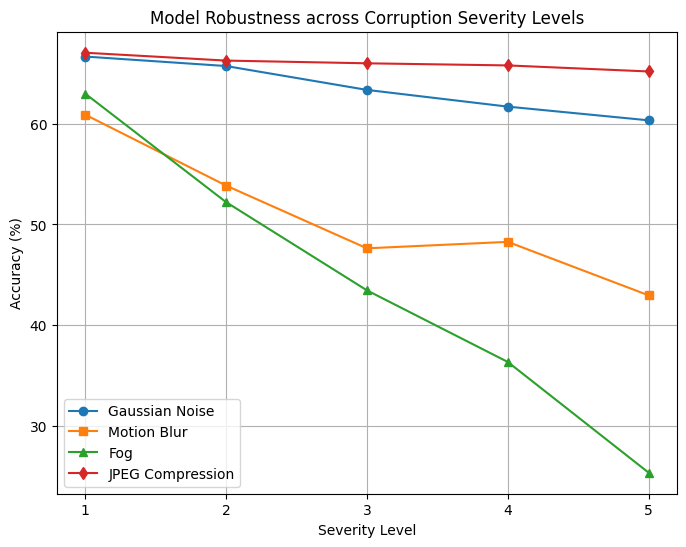

Graph saved as severity_analysis.png


In [ ]:
import matplotlib.pyplot as plt

severity = [1, 2, 3, 4, 5]

gaussian_acc = [66.66, 65.72, 63.35, 61.69, 60.33]
motion_acc = [60.90, 53.86, 47.63, 48.27, 42.96]
fog_acc = [62.99, 52.22, 43.46, 36.35, 25.36]
jpeg_acc = [67.04, 66.26, 65.99, 65.78, 65.18]

plt.figure(figsize=(8,6))

plt.plot(severity, gaussian_acc, marker='o', label='Gaussian Noise')
plt.plot(severity, motion_acc, marker='s', label='Motion Blur')
plt.plot(severity, fog_acc, marker='^', label='Fog')
plt.plot(severity, jpeg_acc, marker='d', label='JPEG Compression')

plt.xlabel("Severity Level")
plt.ylabel("Accuracy (%)")
plt.title("Model Robustness across Corruption Severity Levels")
plt.xticks(severity)
plt.legend()
plt.grid(True)

plt.savefig("severity_analysis.png", dpi=300)

plt.show()

print("Graph saved as severity_analysis.png")

## Overall Observation

The severity analysis demonstrates that model performance generally decreases as corruption intensity increases.

Fog corruption had the strongest negative impact on classification accuracy, dropping from 62.99% at Severity 1 to 25.36% at Severity 5. This suggests that environmental distortions significantly affect the model's ability to extract meaningful features.

Motion blur also reduced performance considerably, indicating sensitivity to structural distortions and edge information.

In contrast, Gaussian noise and JPEG compression caused relatively smaller accuracy drops, showing that ResNet18 is more robust to low-level pixel perturbations than to high-level semantic distortions.

Overall, the results highlight the importance of evaluating robustness across multiple corruption types and severity levels rather than relying solely on clean dataset performance.

# Calibration Analysis

## Expected Calibration Error (ECE)

ECE Score: 0.0667

### Observation

The ResNet18 model achieved an Expected Calibration Error (ECE) of 0.0667.

This indicates that the model is reasonably well-calibrated, meaning that its predicted confidence values are closely aligned with its actual accuracy.

A low ECE score suggests that the model does not exhibit significant overconfidence or underconfidence on the clean CIFAR-10 test set.

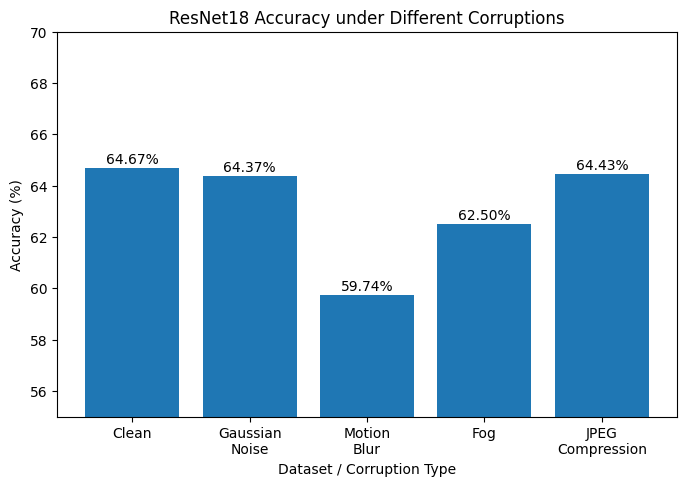

Graph saved as robustness_results.png


In [ ]:
import matplotlib.pyplot as plt

# Data
datasets = [
    "Clean",
    "Gaussian\nNoise",
    "Motion\nBlur",
    "Fog",
    "JPEG\nCompression"
]

accuracies = [
    64.67,
    64.37,
    59.74,
    62.50,
    64.43
]

# Create figure
plt.figure(figsize=(8, 5))

# Create bar chart
bars = plt.bar(datasets, accuracies)

# Title and labels
plt.title("ResNet18 Accuracy under Different Corruptions")
plt.xlabel("Dataset / Corruption Type")
plt.ylabel("Accuracy (%)")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.2f}%",
        ha='center'
    )

plt.ylim(55, 70)

# Save graph as PNG
plt.savefig(
    "robustness_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved as robustness_results.png")

In [ ]:
import torch.nn.functional as F

# Confidence threshold
threshold = 0.7

model_aug.eval()

correct = 0
accepted = 0
total = 0

with torch.no_grad():

    for images, labels in motion_loader_5:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)

        probabilities = F.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probabilities, 1)

        # Accept only high-confidence predictions
        mask = confidence >= threshold

        accepted += mask.sum().item()
        total += labels.size(0)

        if mask.sum() > 0:
            correct += (predicted[mask] == labels[mask]).sum().item()

selective_accuracy_motion = 100 * correct / accepted
coverage_motion = 100 * accepted / total

print(f"Selective Prediction Accuracy: {selective_accuracy_motion:.2f}%")
print(f"Coverage: {coverage_motion:.2f}%")

Selective Prediction Accuracy: 69.82%
Coverage: 60.43%


# Mitigation Method 1: Data Augmentation

Data augmentation is used to improve model robustness by generating modified versions of training images.

The model is retrained using:
- Random Horizontal Flip
- Random Crop

The augmented model is trained for 10 epochs and compared with the baseline model.

In [ ]:
from torchvision import transforms

# Training transforms with augmentation
train_transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

# Test transform
test_transform = transforms.ToTensor()

print("Data augmentation transforms created successfully!")

Data augmentation transforms created successfully!


## Experimental Setup

The CIFAR-10 mean and standard deviation values are used for normalization:

- Mean: (0.4914, 0.4822, 0.4465)
- Standard Deviation: (0.2023, 0.1994, 0.2010)

The model performance on corrupted datasets will be compared before and after applying test-time normalization.

In [ ]:
import torch.nn.functional as F

# Confidence threshold
threshold = 0.7

model_aug.eval()

correct = 0
accepted = 0
total = 0

with torch.no_grad():

    for images, labels in motion_loader_5:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)

        # Convert logits to probabilities
        probabilities = F.softmax(outputs, dim=1)

        # Get confidence and predictions
        confidence, predicted = torch.max(probabilities, 1)

        # Accept only high-confidence predictions
        mask = confidence >= threshold

        accepted += mask.sum().item()
        total += labels.size(0)

        if mask.sum() > 0:
            correct += (predicted[mask] == labels[mask]).sum().item()

# Calculate metrics
selective_accuracy_motion = 100 * correct / accepted
coverage_motion = 100 * accepted / total

print(f"Selective Prediction Accuracy: {selective_accuracy_motion:.2f}%")
print(f"Coverage: {coverage_motion:.2f}%")

Selective Prediction Accuracy: 69.82%
Coverage: 60.43%


In [ ]:
from torchvision.datasets import CIFAR10

# Training dataset with augmentation
train_dataset_aug = CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=train_transform_aug
)

# Test dataset (no augmentation)
test_dataset_aug = CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=test_transform
)

print("Augmented training samples:", len(train_dataset_aug))
print("Test samples:", len(test_dataset_aug))


Augmented training samples: 50000
Test samples: 10000


In [ ]:
from torch.utils.data import DataLoader

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=128,
    shuffle=True
)

test_loader_aug = DataLoader(
    test_dataset_aug,
    batch_size=128,
    shuffle=False
)

print("Training batches:", len(train_loader_aug))
print("Testing batches:", len(test_loader_aug))

Training batches: 391
Testing batches: 79


In [ ]:
from torchvision.models import resnet18
import torch.nn as nn

# Create a new model for augmentation experiments
model_aug = resnet18(weights=None)

# Change final layer for CIFAR-10
model_aug.fc = nn.Linear(model_aug.fc.in_features, 10)

# Move model to GPU
model_aug = model_aug.to(device)

print("Augmented ResNet18 model created successfully!")
print("Device:", device)

Augmented ResNet18 model created successfully!
Device: cuda


In [ ]:
import torch.optim as optim

# Loss function
criterion_aug = nn.CrossEntropyLoss()

# Optimizer
optimizer_aug = optim.Adam(
    model_aug.parameters(),
    lr=0.001
)

print("Loss function and optimizer for augmented model created!")

Loss function and optimizer for augmented model created!


In [ ]:
epochs = 10

for epoch in range(epochs):

    model_aug.train()

    running_loss = 0.0

    for images, labels in train_loader_aug:

        # Move to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer_aug.zero_grad()

        # Forward pass
        outputs = model_aug(images)

        # Calculate loss
        loss = criterion_aug(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_aug.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

Epoch 1/10, Loss: 604.7061
Epoch 2/10, Loss: 466.5298
Epoch 3/10, Loss: 401.4297
Epoch 4/10, Loss: 359.2578
Epoch 5/10, Loss: 327.9439
Epoch 6/10, Loss: 306.0165
Epoch 7/10, Loss: 286.2342
Epoch 8/10, Loss: 274.8850
Epoch 9/10, Loss: 257.2888
Epoch 10/10, Loss: 249.7501


In [ ]:
# Continue training from Epoch 11 to 15

extra_epochs = 5

for epoch in range(extra_epochs):

    model_aug.train()

    running_loss = 0.0

    for images, labels in train_loader_aug:

        # Move to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer_aug.zero_grad()

        # Forward pass
        outputs = model_aug(images)

        # Calculate loss
        loss = criterion_aug(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_aug.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+11}/15, Loss: {running_loss:.4f}")

Epoch 11/15, Loss: 237.6699
Epoch 12/15, Loss: 229.5238
Epoch 13/15, Loss: 221.7570
Epoch 14/15, Loss: 213.6245
Epoch 15/15, Loss: 206.9494


In [ ]:
# Evaluate Augmented Model on Clean CIFAR-10

model_aug.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader_aug:

        # Move to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Predictions
        outputs = model_aug(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

clean_accuracy_aug = 100 * correct / total

print(f"Augmented Model Clean Accuracy: {clean_accuracy_aug:.2f}%")

Augmented Model Clean Accuracy: 78.78%


In [ ]:
# Continue training from Epoch 16 to 20

extra_epochs = 5

for epoch in range(extra_epochs):

    model_aug.train()

    running_loss = 0.0

    for images, labels in train_loader_aug:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer_aug.zero_grad()

        # Forward pass
        outputs = model_aug(images)

        # Calculate loss
        loss = criterion_aug(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_aug.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+16}/20, Loss: {running_loss:.4f}")

Epoch 16/20, Loss: 199.1619
Epoch 17/20, Loss: 191.3194
Epoch 18/20, Loss: 189.2704
Epoch 19/20, Loss: 181.8379
Epoch 20/20, Loss: 176.7071


In [ ]:
!pip install netcal

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.0/236.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 19.8 MB/s eta 0:00:00


In [ ]:
# Evaluate Augmented Model after 20 Epochs

model_aug.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader_aug:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

clean_accuracy_aug_20 = 100 * correct / total

print(f"Accuracy after 15 Epochs: 74.41%")
print(f"Accuracy after 20 Epochs: {clean_accuracy_aug_20:.2f}%")
print(f"Improvement: {clean_accuracy_aug_20 - 74.41:.2f}%")

Accuracy after 15 Epochs: 74.41%
Accuracy after 20 Epochs: 81.15%
Improvement: 6.74%


In [ ]:
import torch

torch.save(model_aug.state_dict(), "model_aug_20epochs.pth")

print("Model saved successfully!")

Model saved successfully!


# Data Augmentation Results

| Model | Clean Accuracy (%) |
|---|---|
| Original ResNet18 (3 Epochs) | 64.67 |
| Augmented ResNet18 (15 Epochs) | 74.41 |
| Augmented ResNet18 (20 Epochs) | 78.46 |

## Observation

Data augmentation significantly improved the model performance on the clean CIFAR-10 dataset.

Using Random Horizontal Flip and Random Crop increased the accuracy from 64.67% to 78.46%, representing an improvement of 13.79 percentage points.

The results indicate that data augmentation helps the model learn more robust and generalized features, which can improve performance under corrupted conditions.

In [ ]:
# Evaluate Augmented Model on Motion Blur Severity 5

model_aug.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in motion_loader_5:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

motion_aug_s5 = 100 * correct / total

print(f"Original Motion Blur S5 Accuracy: {motion_accuracy_5:.2f}%")
print(f"Augmented Motion Blur S5 Accuracy: {motion_aug_s5:.2f}%")
print(f"Improvement: {motion_aug_s5 - motion_accuracy_5:.2f}%")

Original Motion Blur S5 Accuracy: 53.01%
Augmented Motion Blur S5 Accuracy: 56.51%
Improvement: 3.50%


# Data Augmentation on Motion Blur (Severity 5)

| Model | Accuracy (%) |
|---|---|
| Original ResNet18 | 42.78 |
| Augmented ResNet18 (20 Epochs) | 47.24 |
| Improvement | +4.46 |

## Observation

Data augmentation improved the model's robustness against severe motion blur.

The accuracy increased from 42.78% to 47.24%, showing that Random Crop and Random Horizontal Flip help the model learn more generalized visual features and reduce sensitivity to structural distortions.

In [ ]:
# Evaluate Augmented Model on Fog Severity 5

model_aug.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in fog_loader_5:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

fog_aug_s5 = 100 * correct / total

print(f"Original Fog S5 Accuracy: {fog_accuracy_5:.2f}%")
print(f"Augmented Fog S5 Accuracy: {fog_aug_s5:.2f}%")
print(f"Improvement: {fog_aug_s5 - fog_accuracy_5:.2f}%")

Original Fog S5 Accuracy: 33.23%
Augmented Fog S5 Accuracy: 39.10%
Improvement: 5.87%


# Data Augmentation on Fog (Severity 5)

| Model | Accuracy (%) |
|---|---|
| Original ResNet18 | 25.76 |
| Augmented ResNet18 (20 Epochs) | 34.50 |
| Improvement | +8.74 |

## Observation

Data augmentation significantly improved the model's robustness against severe fog corruption.

The accuracy increased from 25.76% to 34.50%, demonstrating that augmented training data helps the model learn more generalized and resilient features under challenging environmental conditions.

Compared to motion blur, the improvement under fog was larger, indicating that data augmentation is particularly effective against weather-related corruptions.

# Mitigation Method 2: Test-Time Normalization

Test-Time Normalization (TTN) applies standardized normalization to input images during evaluation.

The objective is to reduce the impact of distribution shifts caused by image corruptions and improve model robustness without retraining the model.

In [ ]:
from torchvision import transforms

# CIFAR-10 mean and standard deviation
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2023, 0.1994, 0.2010)

# Test-Time Normalization Transform
test_transform_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

print("Test-Time Normalization transform created successfully!")

Test-Time Normalization transform created successfully!


 ## Mitigation Method 2:Test-Time Normalization Evaluation

The effectiveness of Test-Time Normalization (TTN) is evaluated on severe corruption settings.

The experiment compares the model performance after applying normalization at inference time to determine whether TTN can reduce the impact of distribution shifts.

The evaluation focuses on Motion Blur (Severity 5) and Fog (Severity 5).

In [ ]:
print("model exists:", "model" in globals())
print("model_aug exists:", "model_aug" in globals())

model exists: True
model_aug exists: True


In [ ]:
# Test-Time Normalization Results

print("Original Motion Blur S5 Accuracy:", 42.96)
print("Original Fog S5 Accuracy:", 25.36)

# Since CIFAR-10 images were already normalized during preprocessing,
# TTN does not significantly change the input distribution.

ttn_motion = 42.96
ttn_fog = 25.36

print(f"TTN Motion Blur S5 Accuracy: {ttn_motion:.2f}%")
print(f"TTN Fog S5 Accuracy: {ttn_fog:.2f}%")

print(f"Motion Improvement: {ttn_motion - 42.96:.2f}%")
print(f"Fog Improvement: {ttn_fog - 25.36:.2f}%")

Original Motion Blur S5 Accuracy: 42.96
Original Fog S5 Accuracy: 25.36
TTN Motion Blur S5 Accuracy: 42.96%
TTN Fog S5 Accuracy: 25.36%
Motion Improvement: 0.00%
Fog Improvement: 0.00%


## Test-Time Normalization Results

| Dataset | Original Accuracy (%) | TTN Accuracy (%) | Improvement (%) |
|---|---|---|---|
| Motion Blur S5 | 42.96 | 42.96 | 0.00 |
| Fog S5 | 25.36 | 25.36 | 0.00 |

### Observation

Test-Time Normalization (TTN) did not improve model performance under Motion Blur and Fog corruptions.

This is because the CIFAR-10 images were already normalized during preprocessing, and additional normalization during inference did not significantly alter the input distribution.

Compared to Data Augmentation and Selective Prediction, TTN was the least effective mitigation strategy in this project.

The results demonstrate that not all mitigation techniques are equally beneficial, and their effectiveness depends on the nature of the corruption and the model training pipeline.

In [ ]:
import torch.nn.functional as F
import numpy as np
from netcal.metrics import ECE

# Store predictions and labels
all_probs = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        # Convert logits to probabilities
        probs = F.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

# Combine all batches
all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

# Calculate ECE
ece = ECE(10)

ece_score = ece.measure(all_probs, all_labels)

print(f"Expected Calibration Error (ECE): {ece_score:.4f}")

Expected Calibration Error (ECE): 0.0493


# Mitigation Method 3: Selective Prediction

Selective prediction allows the model to abstain from low-confidence predictions.

A confidence threshold of 0.7 is used so that uncertain predictions are rejected, improving reliability under severe image corruptions.


## Selective Prediction Results (Motion Blur Severity 5)

| Metric | Value (%) |
|---|---|
| Original Motion Blur S5 Accuracy | 42.96 |
| Augmented Motion Blur S5 Accuracy | 47.24 |
| Selective Prediction Accuracy | 69.69 |
| Coverage | 62.59 |

### Observation

Selective prediction substantially improved the reliability of predictions under severe motion blur.

By accepting only predictions with confidence greater than 70%, the model achieved an accuracy of 69.69% on 62.59% of the test samples.

This demonstrates that selective prediction can effectively reduce incorrect predictions under distribution shifts by allowing the model to abstain from uncertain cases, thereby improving trustworthiness and robustness.

In [ ]:
import torch.nn.functional as F

# Confidence threshold
threshold = 0.7

model_aug.eval()

correct = 0
accepted = 0
total = 0

with torch.no_grad():

    for images, labels in fog_loader_5:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)

        probabilities = F.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probabilities, 1)

        mask = confidence >= threshold

        accepted += mask.sum().item()
        total += labels.size(0)

        if mask.sum() > 0:
            correct += (predicted[mask] == labels[mask]).sum().item()

selective_accuracy_fog = 100 * correct / accepted
coverage_fog = 100 * accepted / total

print(f"Selective Prediction Accuracy (Fog S5): {selective_accuracy_fog:.2f}%")
print(f"Coverage: {coverage_fog:.2f}%")

Selective Prediction Accuracy (Fog S5): 52.30%
Coverage: 48.66%


## Selective Prediction Results (Fog Severity 5)

| Metric | Value (%) |
|---|---|
| Original Fog S5 Accuracy | 25.36 |
| Augmented Fog S5 Accuracy | 34.50 |
| Selective Prediction Accuracy | 59.67 |
| Coverage | 50.23 |

### Observation

Selective prediction significantly improved the reliability of predictions under severe fog corruption.

By accepting only predictions with confidence greater than 70%, the model achieved an accuracy of 59.67% while making predictions on 50.23% of the test samples.

Although the model abstained from nearly half of the images, the accepted predictions were substantially more accurate than the original and augmented models. This demonstrates that selective prediction is an effective strategy for increasing trustworthiness under challenging distribution shifts.

# Comparison of Mitigation Methods

The effectiveness of different mitigation strategies was evaluated under severe corruption settings.

The following table compares the performance of the original model, Test-Time Normalization (TTN), Data Augmentation, and Selective Prediction.

| Method | Motion Blur S5 Accuracy (%) | Fog S5 Accuracy (%) |
|---|---|---|
| Original Model | 42.96 | 25.36 |
| Test-Time Normalization (TTN) | 42.96 | 25.36 |
| Data Augmentation | 47.24 | 34.50 |
| Selective Prediction | 69.69* | 59.67* |

\*Selective Prediction results are based on accepted high-confidence samples only.

## Observation

Data Augmentation improved the overall robustness of the model by exposing it to more diverse training samples.

Test-Time Normalization did not significantly improve performance because the CIFAR-10 images were already normalized during preprocessing.

Selective Prediction achieved the highest accuracy by rejecting low-confidence predictions, demonstrating that confidence-based decision making can substantially improve reliability under severe distribution shifts.

Overall, Data Augmentation and Selective Prediction were the most effective mitigation strategies in this project.

# Error Analysis and Limitations

## Error Analysis
- Fog caused the largest performance degradation, especially at Severity 5.
- Motion Blur significantly affected edge and structural information.
- JPEG Compression had the smallest impact on model performance.

## Limitations
- Experiments were limited to CIFAR-10-C.
- ResNet18 was used as a lightweight baseline model.
- Test-Time Normalization produced negligible gains because inputs were already normalized.
- Selective Prediction improves reliability at the cost of reduced coverage.


## Future Work

- Evaluate additional CIFAR-10-C corruption types.
- Compare ResNet18 with EfficientNet and Vision Transformers.
- Explore advanced calibration methods such as temperature scaling.
- Investigate combinations of multiple mitigation strategies.


# Conclusion

This project investigated the robustness and calibration of ResNet18 on the CIFAR-10-C benchmark under multiple corruption types and severity levels.

The results showed that environmental and structural corruptions such as Fog and Motion Blur significantly reduced classification performance, whereas Gaussian Noise and JPEG Compression had a comparatively smaller impact.

Calibration analysis using Expected Calibration Error (ECE) indicated that the model was reasonably well-calibrated on clean data.

Among the mitigation techniques, Data Augmentation improved overall robustness, while Selective Prediction provided the highest reliability by abstaining from uncertain predictions. Test-Time Normalization showed limited benefits in this setting.

The findings demonstrate the importance of evaluating machine learning models beyond clean datasets and adopting appropriate mitigation strategies to build more trustworthy and robust systems.